# DI 501 Term Project Final Report
**Eda Onay - ID: 2739415**

**My research question:s**

- **RQ1.** Do high-level audio features (acousticness, energy, danceability, etc.)
  differ systematically between older songs (≤1980) and modern songs (≥2010)?
- **RQ2.** Does adding lyric-derived features on top of audio features improve
  decade prediction (accuracy and macro-F1) over a naive majority-class
  baseline, and does the choice of model family (Logistic Regression vs.
  Random Forest) change the answer?

## 1. Import Data

In [ ]:
import sys
import warnings
from pathlib import Path

import pandas as pdeda
import numpy as npeda
import matplotlib.pyplot as plteda

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

python: 3.9.6
pandas: 2.3.3
numpy : 2.0.2


## 2. Project paths

In [2]:
cwd = Path.cwd()

project_root = cwd
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if not (project_root / "data").exists():
    raise FileNotFoundError("Project root with 'data' folder could not be found.")

data_path        = project_root / "data"
reports_path     = project_root / "reports"
figures_path     = reports_path / "figures"
csv_output_path  = reports_path / "generated csv files"

figures_path.mkdir(parents=True, exist_ok=True)
csv_output_path.mkdir(parents=True, exist_ok=True)

print("project_root :", project_root)
print("data_path    :", data_path)
print("figures_path :", figures_path)
print("csv outputs  :", csv_output_path)


project_root : /Users/edaonay/Downloads/DI501_EdaOnay_InterimPhase_2739415
data_path    : /Users/edaonay/Downloads/DI501_EdaOnay_InterimPhase_2739415/data
figures_path : /Users/edaonay/Downloads/DI501_EdaOnay_InterimPhase_2739415/reports/figures
csv outputs  : /Users/edaonay/Downloads/DI501_EdaOnay_InterimPhase_2739415/reports/generated csv files


## 3. Loading the raw tables
Four CSVs from the Spotify dataset were used:

| csv file name | grain | role |
|---|---|---|
| spotify_tracks.csv | one row per track | high-level audio features and popularity |
| spotify_albums.csv | one row per track (linked through track_id) | release date and album type |
| spotify_artists.csv | one row per (artist, track) pair | artist popularity and follower count |
| lyrics_features.csv | one row per track | lyric-derived text statistics |

low_level_audio_features.csv (208 spectral/MFCC/Chroma features) is not
loaded, please check Section 6 for my reasonings.

In [3]:
tracks  = pdeda.read_csv(data_path / "spotify_tracks.csv")
albums  = pdeda.read_csv(data_path / "spotify_albums.csv")
artists = pdeda.read_csv(data_path / "spotify_artists.csv")
lyrics  = pdeda.read_csv(data_path / "lyrics_features.csv")

print("tracks  :", tracks.shape)
print("albums  :", albums.shape)
print("artists :", artists.shape)
print("lyrics  :", lyrics.shape)


tracks  : (101939, 32)
albums  : (75511, 16)
artists : (56129, 9)
lyrics  : (94954, 8)


## 4. Cleaning each table
Three small clean-up steps before the merge:

1. I dropped unnamed index columns left over from earlier exports,
2. I renamed tracks.id as track_id so all four tables share a join key,
3. I collapsed the artist table (which is at artist x track grain) to one row per
   track by keeping the most popular artist's stats. This choice is
   deliberate because I am predicting decade and the most popular collaborator
   is the strongest signal of an era,
4. I kept only the columns I actually needed downstream,
5. I recoded the sentinel value -1 in lyric columns as NaN, otherwise the
   means and percentiles would be misleading.

In [4]:
def drop_unnamed(df):
    return df.loc[:, ~df.columns.str.contains("^Unnamed")]

tracks  = drop_unnamed(tracks)
albums  = drop_unnamed(albums)
artists = drop_unnamed(artists)
lyrics  = drop_unnamed(lyrics)

if "id" in tracks.columns and "track_id" not in tracks.columns:
    tracks = tracks.rename(columns={"id": "track_id"})

# artist table → track-level (max across collaborators)
artist_agg = artists.groupby("track_id", as_index=False).agg({
    "artist_popularity": "max",
    "followers": "max",
})

track_keep = [
    "track_id",
    "acousticness", "danceability", "energy", "instrumentalness",
    "liveness", "speechiness", "tempo", "valence", "popularity",
]
tracks_small = tracks[track_keep].drop_duplicates()

album_keep = ["track_id", "release_date", "album_type", "total_tracks"]
albums_small = albums[album_keep].drop_duplicates()

lyric_keep = [
    "track_id",
    "mean_syllables_word", "mean_words_sentence", "n_sentences",
    "n_words", "sentence_similarity", "vocabulary_wealth",
]
lyrics_small = lyrics[lyric_keep].drop_duplicates()

lyric_cols = lyric_keep[1:]
for col in lyric_cols:
    lyrics_small[col] = lyrics_small[col].replace(-1, npeda.nan)

print("tracks_small :", tracks_small.shape)
print("albums_small :", albums_small.shape)
print("artist_agg   :", artist_agg.shape)
print("lyrics_small :", lyrics_small.shape)


tracks_small : (101939, 10)
albums_small : (75511, 4)
artist_agg   : (44895, 3)
lyrics_small : (94954, 7)


## 5. Merging into a single track-level frame
Left-join everything onto the tracks table so I kept every track even when
lyrics or artist info is missing, I will measure that missingness in the future parts.

In [ ]:
df = tracks_small.merge(albums_small, on="track_id", how="left")
df = df.merge(artist_agg,   on="track_id", how="left")
df = df.merge(lyrics_small, on="track_id", how="left")

print("merged shape:", df.shape)
df.head(3)

merged shape: (101939, 21)


,track_id,acousticness,danceability,energy,instrumentalness,liveness,speechiness,tempo,valence,popularity,...,album_type,total_tracks,artist_popularity,followers,mean_syllables_word,mean_words_sentence,n_sentences,n_words,sentence_similarity,vocabulary_wealth
0,5qljLQuKnNJf4F4vfxQB0V,0.294,0.698,0.606,0.000003,0.151,0.0262,115.018,0.622,28.0,...,single,2.0,NaN,NaN,1.39,3.13,39.0,208.0,0.02834,0.64
1,3VAX2MJdmdqARLSU5hPMpm,0.863,0.719,0.308,0.000000,0.253,0.9220,115.075,0.589,31.0,...,album,13.0,36.0,2965.0,1.44,25.56,106.0,5106.0,0.00018,0.57
2,1L3YAhsEMrGVvCgDXj2TYn,0.750,0.466,0.931,0.000000,0.938,0.9440,79.565,0.085,31.0,...,NaN,NaN,NaN,NaN,1.22,3.59,71.0,396.0,0.14326,0.37


## 5.1 Derived time features
- release_year was parsed from release_date.
- decade label was used as the ML target.
- era_group - coarse older (≤1980) / modern (≥2010) / middle split
 was used only for the descriptive RQ1 contrast.

In [ ]:
df["release_date"] = pdeda.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year

df["decade_num"] = (df["release_year"] // 10) * 10
df["decade"]     = df["decade_num"].astype("Int64").astype(str) + "s"
df.loc[df["release_year"].isna(), "decade"] = npeda.nan

df["era_group"] = npeda.select(
    [df["release_year"] <= 1980, df["release_year"] >= 2010],
    ["older", "modern"],
    default="middle",
)

print(df[["release_year", "decade", "era_group"]].head())

   release_year decade era_group
0        2018.0  2010s    modern
1        2011.0  2010s    modern
2           NaN    NaN    middle
3           NaN    NaN    middle
4           NaN    NaN    middle


## 5.2 Data-quality checks
1. Missingness per column: The lyrics columns are sparser than audio columns
   because not every track is matched to a lyrics row.
2. Duplicates: There exist rows and track_id collisions.
3. Time coverage: Distribution of release years and decades.

In [ ]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("Missing value percentage (top 20):")
print(missing_pct.head(20).round(2))

print("\nDuplicate rows in merged df :", df.duplicated().sum())
print("Duplicate track_id values    :", df["track_id"].duplicated().sum())

Missing value percentage (top 20):
followers              55.96
artist_popularity      55.96
decade                 31.71
decade_num             31.71
release_year           31.71
release_date           31.71
total_tracks           25.93
album_type             25.93
vocabulary_wealth      22.09
sentence_similarity    22.09
n_words                22.09
n_sentences            22.09
mean_words_sentence    22.09
mean_syllables_word    22.09
track_id                0.00
acousticness            0.00
popularity              0.00
valence                 0.00
tempo                   0.00
speechiness             0.00
dtype: float64

Duplicate rows in merged df : 0
Duplicate track_id values    : 0


In [ ]:
print("Release year summary:")
print(df["release_year"].describe())

print("\nDecade distribution:")
print(df["decade"].value_counts(dropna=False).sort_index())

print("\nEra-group distribution:")
print(df["era_group"].value_counts(dropna=False))

Release year summary:


count    69611.000000
mean      2014.297999
std          7.559202
min       1926.000000
25%       2014.000000
50%       2017.000000
75%       2018.000000
max       2019.000000
Name: release_year, dtype: float64

Decade distribution:
decade
1920s        1
1930s        2
1940s        2
1950s       36
1960s      183
1970s      403
1980s      736
1990s     2472
2000s     6448
2010s    59328
NaN      32328
Name: count, dtype: int64

Era-group distribution:
era_group
modern    59328
middle    41942
older       669
Name: count, dtype: int64


## 5.3 Descriptive statistics (for RQ1)

In [ ]:
selected_features = [
    "acousticness", "danceability", "energy", "tempo",
    "mean_syllables_word", "mean_words_sentence", "n_words", "vocabulary_wealth",
]

desc_table = df[selected_features].describe().T[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]
desc_table.to_csv(csv_output_path / "descriptive_statistics_final_edaonay_2739415.csv")
desc_table

,count,mean,std,min,25%,50%,75%,max
acousticness,101939.0,0.352124,0.334855,0.00,0.0407,0.238,0.645,0.996
danceability,101939.0,0.586015,0.177724,0.00,0.4800,0.610,0.714,0.989
energy,101939.0,0.586479,0.260170,0.00,0.4110,0.629,0.798,1.000
tempo,101939.0,118.358527,30.224074,0.00,95.9730,118.067,136.045,244.035
mean_syllables_word,79420.0,1.456284,0.368089,1.00,1.2100,1.310,1.640,4.000
mean_words_sentence,79420.0,4.488114,10.295689,0.33,2.9800,3.500,4.130,819.200
n_words,79420.0,379.081415,940.457005,1.00,188.0000,273.000,385.000,39111.000
vocabulary_wealth,79420.0,0.557464,0.120337,0.00,0.4900,0.570,0.650,0.780


## 5.4 Older vs. Modern Eras (for RQ1)
Side-by-side summary of the two acoustic features that the literature (at least, according to the articles I found) most
often associates with era shifts: acousticness and energy.

In [ ]:
plot_df = df[df["era_group"].isin(["older", "modern"])].copy()

group_summary = plot_df.groupby("era_group")[["acousticness", "energy"]].agg(
    ["count", "mean", "std", "median"]
)
group_summary.to_csv(csv_output_path / "older_vs_modern_summary_final_edaonay_2739415.csv")
group_summary

acousticness                            energy                      \
                 count      mean       std median  count      mean       std   
era_group                                                                      
modern           59328  0.312408  0.325584  0.178  59328  0.613926  0.247214   
older              669  0.470455  0.319877  0.481    669  0.514743  0.239265   

                  
          median  
era_group         
modern     0.655  
older      0.510

## 5.5 Figure 1: Distribution of tracks by release decade
This figure shows the heavy skew toward 2010s/2020s tracks. This skew is what drives the
majority-class baseline in Section 7 to a deceptively high accuracy.

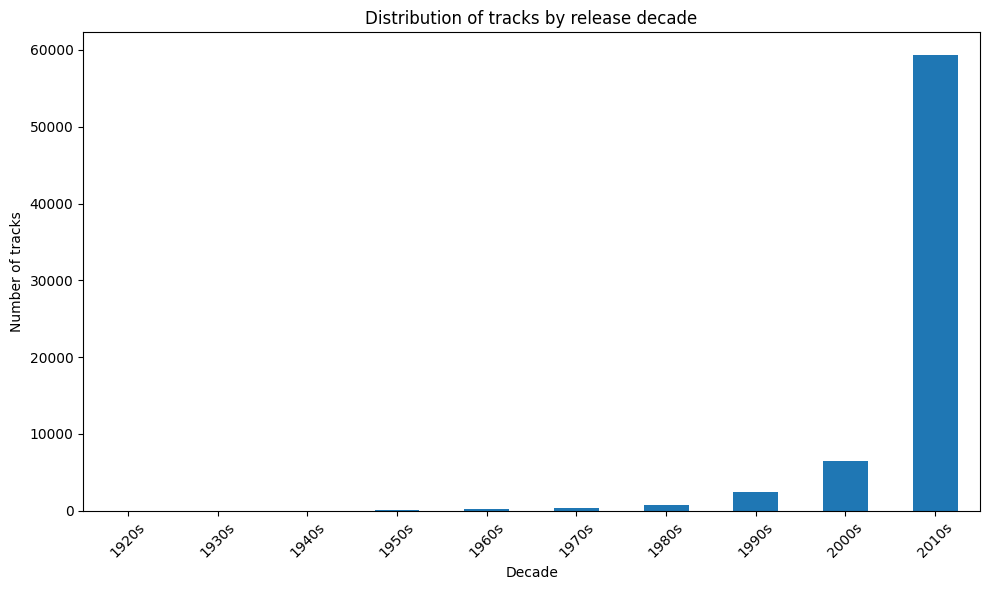

In [11]:
decade_counts = df["decade"].value_counts().sort_index()

plteda.figure(figsize=(10, 6))
decade_counts.plot(kind="bar")
plteda.xlabel("Decade")
plteda.ylabel("Number of tracks")
plteda.title("Distribution of tracks by release decade")
plteda.xticks(rotation=45)
plteda.tight_layout()
plteda.savefig(figures_path / "figure_decade_distribution_final_edaonay_2739415.pdf",
               bbox_inches="tight")
plteda.show()


## 5.6 Figure 2: Acousticness by era group (for RQ1)

<Figure size 800x600 with 0 Axes>

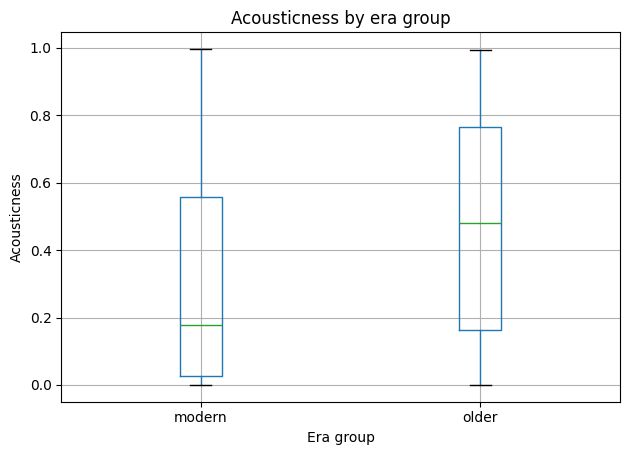

In [12]:
plteda.figure(figsize=(8, 6))
plot_df.boxplot(column="acousticness", by="era_group")
plteda.xlabel("Era group")
plteda.ylabel("Acousticness")
plteda.title("Acousticness by era group")
plteda.suptitle("")
plteda.tight_layout()
plteda.savefig(figures_path / "figure_acousticness_boxplot_final_edaonay_2739415.pdf",
               bbox_inches="tight")
plteda.show()


## 5.7 Figure 3: Energy by era group (RQ1)

<Figure size 800x600 with 0 Axes>

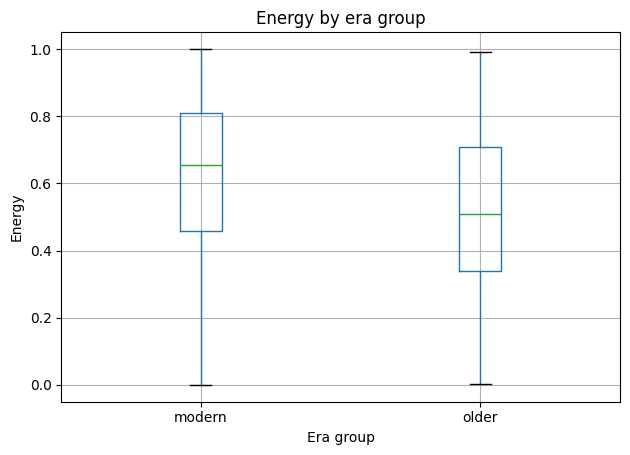

In [13]:
plteda.figure(figsize=(8, 6))
plot_df.boxplot(column="energy", by="era_group")
plteda.xlabel("Era group")
plteda.ylabel("Energy")
plteda.title("Energy by era group")
plteda.suptitle("")
plteda.tight_layout()
plteda.savefig(figures_path / "figure_energy_boxplot_final_edaonay_2739415.pdf",
               bbox_inches="tight")
plteda.show()


## 6. Feature Selection:
According to the feedback I received for my interim report, you asked me to explain whether feature selection is an
informed search, based on literature, or driven by data availability. My method is actually a combination, I work from the full set of interpretable,
track-level features the dataset provides, grouped by source.

### 6.1 Audio features
acousticness, danceability, energy, instrumentalness, liveness, speechiness,
tempo, valence. These are the entire set of high-level audio descriptors
the Spotify Web API returns for a track. I used all of them rather than
sub-selecting for the fact that they are already low-dimensional, so feature pruning
gives little benefit, and because prior work on Spotify-API-based modelling
(Interiano et al. 2018; the popularity-prediction papers in my articles folder)
consistently treats this set as a single audio profile.

### 6.2 Artist context features
artist_popularity, followers: These are aggregated to the track level by
taking the max across data. They are not audio features however,
they are the only track-level metadata the dataset exposes that is not
literally the target (release_date) or a near-duplicate of it.

### 6.3 Lyric features
mean_syllables_word, mean_words_sentence, n_sentences, n_words,
sentence_similarity, vocabulary_wealth: This is the entire set of lyric
statistics in lyrics_features.csv, no pruning was done here, every column was
used.

### 6.4 Excluded (The explanation I referred to in the beginning is this): low-level audio dataset
low_level_audio_features.csv contains 208 MFCC, Chroma, MEL, Tonnetz and
spectral statistics. I excluded them for two reasons listed below:

1. Interpretability: RQ2 focuses on whether lyrical features add value on top of
   audio features. Mixing in 208 spectral features would probably dwarf the 6 lyric
   features and make the ablation result hard to read.
2. Tractability: The file is almost 400 MB and the spectral columns are highly
   correlated, using them properly would require a separate dimensionality
   reduction step and I think that is out of our scope for this report so I made this decision.

I explained this in my report as a clear direction for possible future/follow-up work.

### 6.5 Target
decade: The 10-year bucket of the release year. Classes with fewer than
10 samples are dropped so that stratified train/test splits can remain stable.

In [14]:
ml_features = [
    # audio (8)
    "acousticness", "danceability", "energy", "instrumentalness",
    "liveness", "speechiness", "tempo", "valence",
    # artist context (2)
    "artist_popularity", "followers",
    # lyrics (6)
    "mean_syllables_word", "mean_words_sentence", "n_sentences",
    "n_words", "sentence_similarity", "vocabulary_wealth",
]

audio_features  = ml_features[:10]   # audio + artist context (no lyrics)
lyric_features  = ml_features[10:]   # lyric block

print("audio block :", audio_features)
print("lyric block :", lyric_features)


audio block : ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'speechiness', 'tempo', 'valence', 'artist_popularity', 'followers']
lyric block : ['mean_syllables_word', 'mean_words_sentence', 'n_sentences', 'n_words', 'sentence_similarity', 'vocabulary_wealth']


## 7. ML dataset and naive baseline
Two filters were applied:

1. I dropped rows where the target (release_year, decade) is missing,
2. I dropped rows where any of the chosen features is missing: This is the
   complete-case dataset used for every model below,
3. I dropped decades with fewer than 10 samples so that stratified splits do not
   error out.

The naive baseline is DummyClassifier(strategy="most_frequent"). Because the
dataset is heavily skewed toward 2010s tracks, this baseline gets very high
accuracy but near-zero macro-F1 / balanced accuracy, which is exactly the pattern any
useful model has to overcome.

In [15]:
ml_df = df[["track_id", "release_year", "decade"] + ml_features].copy()
ml_df = ml_df.dropna(subset=["release_year", "decade"])
ml_df_complete = ml_df.dropna(subset=ml_features).copy()

# Heavy-tailed count columns get a log1p transform before any scaling so
# Logistic Regression does not suffer numerical overflow on the few rows
# with very large `followers` / `n_words` values. Tree models are scale
# invariant so this does not hurt them either.
heavy_tailed = ["followers", "n_words", "n_sentences"]
for col in heavy_tailed:
    ml_df_complete[col] = npeda.log1p(ml_df_complete[col].clip(lower=0))

min_class_size = 10
decade_counts_ml = ml_df_complete["decade"].value_counts()
valid_decades    = decade_counts_ml[decade_counts_ml >= min_class_size].index
ml_df_complete   = ml_df_complete[ml_df_complete["decade"].isin(valid_decades)].copy()

print("rows before complete-case filter :", ml_df.shape[0])
print("rows after  complete-case filter :", ml_df_complete.shape[0])
print("log1p-transformed columns        :", heavy_tailed)
print("\nDecade distribution after filtering:")
print(ml_df_complete["decade"].value_counts().sort_index())

ml_df_complete.to_csv(csv_output_path / "ml_dataset_ready_final_edaonay_2739415.csv",
                     index=False)


rows before complete-case filter : 69611
rows after  complete-case filter : 28921
log1p-transformed columns        : ['followers', 'n_words', 'n_sentences']

Decade distribution after filtering:
decade
1950s       13
1960s       59
1970s      109
1980s      241
1990s      881
2000s     2564
2010s    25054
Name: count, dtype: int64


In [ ]:
X = ml_df_complete[ml_features]
y = ml_df_complete["decade"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

baseline_results = pdeda.DataFrame({
    "Metric": ["Accuracy", "Macro-F1", "Balanced Accuracy"],
    "Naive Baseline Score": [
        accuracy_score(y_test, y_pred_dummy),
        f1_score(y_test, y_pred_dummy, average="macro"),
        balanced_accuracy_score(y_test, y_pred_dummy),
    ],
})
baseline_results.to_csv(
    csv_output_path / "naive_baseline_results_final_edaonay_2739415.csv",
    index=False,
)
baseline_results

,Metric,Naive Baseline Score
0,Accuracy,0.866206
1,Macro-F1,0.132615
2,Balanced Accuracy,0.142857


## 8. RQ2: Does adding lyric features help?
This section of my work is the direct answer to the interim feedback I received that RQ2 should not
leave the reader with a to some extent conclusion. I compared two model
families x two feature sets, all evaluated on the same train/test split
that the naive baseline used.

| condition | features | model |
|---|---|---|
| LogReg / audio       | audio + artist context | Logistic Regression |
| LogReg / audio+lyric | audio + artist + lyrics | Logistic Regression |
| RF / audio           | audio + artist context | Random Forest |
| RF / audio+lyric     | audio + artist + lyrics | Random Forest |

Two implementation choices that matter for reading the table:

- class_weight= "balanced" was enabled on both estimators. Without it, the 86 % share of 2010s tracks lets a model achieve almost a 0.866 accuracy by always
  predicting "2010s", which makes the lyric ablation invisible. Balanced class
  weights force the model to put effort into the minority decades, so the
  improvement (or lack of it) from lyrics actually shows up.
- Logistic Regression is wrapped in a StandardScaler because it is
  scale-sensitive whereas Random Forest is not.

Headline metric for this section is macro-F1: It averages F1 across the
seven decade classes with equal weight, so it cannot be inflated by the
2010s majority.

In [17]:
def build_pipeline(model_name, random_state=42):
    """Both models use class_weight='balanced' so the heavy 2010s skew does
    not cause them to collapse to the majority class — without this the
    models are mathematically allowed to score ~0.866 accuracy by predicting
    "2010s" every time, which makes the lyric ablation invisible."""
    if model_name == "logreg":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                solver="lbfgs", penalty="l2", C=0.5,
                max_iter=4000, n_jobs=-1,
                class_weight="balanced",
                random_state=random_state,
            )),
        ])
    if model_name == "rf":
        return Pipeline([
            ("clf", RandomForestClassifier(
                n_estimators=300, n_jobs=-1,
                class_weight="balanced",
                random_state=random_state,
            )),
        ])
    raise ValueError(model_name)


def evaluate(model_name, feature_set_name, feature_cols):
    pipe = build_pipeline(model_name)
    # The intermediate optimisation steps of LBFGS can produce harmless
    # overflow warnings on heavy-tailed columns; we suppress them here so
    # the report cells stay readable. The final fitted model is unaffected.
    with npeda.errstate(all="ignore"), warnings.catch_warnings():
        warnings.simplefilter("ignore")
        pipe.fit(X_train[feature_cols], y_train)
        y_pred = pipe.predict(X_test[feature_cols])
    return {
        "Model": model_name,
        "Feature set": feature_set_name,
        "n features": len(feature_cols),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro-F1": f1_score(y_test, y_pred, average="macro"),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    }


rows = []
for model_name in ["logreg", "rf"]:
    rows.append(evaluate(model_name, "audio",       audio_features))
    rows.append(evaluate(model_name, "audio+lyric", audio_features + lyric_features))

ablation = pdeda.DataFrame(rows)
ablation


/Users/edaonay/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/edaonay/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/edaonay/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/edaonay/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/edaonay/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linea

/Users/edaonay/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/edaonay/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/edaonay/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/edaonay/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/edaonay/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linea

,Model,Feature set,n features,Accuracy,Macro-F1,Balanced Accuracy
0,logreg,audio,10,0.514952,0.144464,0.281505
1,logreg,audio+lyric,16,0.505618,0.144198,0.237229
2,rf,audio,10,0.866033,0.132601,0.142829
3,rf,audio+lyric,16,0.866033,0.155141,0.154955


## 8.1 Combined comparison table

In [18]:
baseline_row = pdeda.DataFrame([{
    "Model": "dummy",
    "Feature set": "majority-class",
    "n features": 0,
    "Accuracy": accuracy_score(y_test, y_pred_dummy),
    "Macro-F1": f1_score(y_test, y_pred_dummy, average="macro"),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_dummy),
}])

comparison = pdeda.concat([baseline_row, ablation], ignore_index=True)
comparison.to_csv(
    csv_output_path / "model_comparison_final_edaonay_2739415.csv",
    index=False,
)
comparison


,Model,Feature set,n features,Accuracy,Macro-F1,Balanced Accuracy
0,dummy,majority-class,0,0.866206,0.132615,0.142857
1,logreg,audio,10,0.514952,0.144464,0.281505
2,logreg,audio+lyric,16,0.505618,0.144198,0.237229
3,rf,audio,10,0.866033,0.132601,0.142829
4,rf,audio+lyric,16,0.866033,0.155141,0.154955


## 8.2 Figure 4: Macro-F1 by model and feature set
Macro-F1 is the right metric to read for my RQ2 because accuracy on this dataset
is dominated by the majority decade. A taller "audio+lyric" bar than the
matching "audio" bar means lyric features carry independent signal on top of
the audio profile.

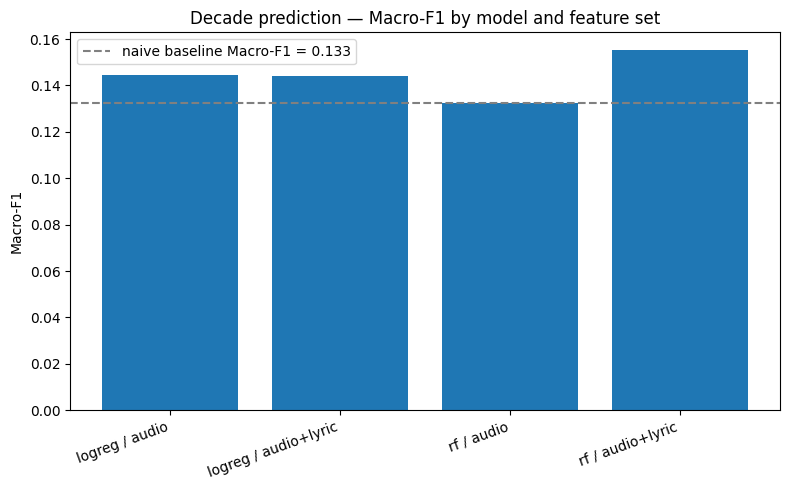

In [19]:
focus = comparison[comparison["Model"] != "dummy"].copy()
focus["label"] = focus["Model"] + " / " + focus["Feature set"]

plteda.figure(figsize=(8, 5))
plteda.bar(focus["label"], focus["Macro-F1"])
plteda.axhline(
    y=baseline_row["Macro-F1"].iloc[0],
    linestyle="--", color="grey",
    label=f"naive baseline Macro-F1 = {baseline_row['Macro-F1'].iloc[0]:.3f}",
)
plteda.ylabel("Macro-F1")
plteda.title("Decade prediction — Macro-F1 by model and feature set")
plteda.xticks(rotation=20, ha="right")
plteda.legend()
plteda.tight_layout()
plteda.savefig(
    figures_path / "figure_model_comparison_final_edaonay_2739415.pdf",
    bbox_inches="tight",
)
plteda.show()


## 8.3 Lyric-uplift summary (for RQ2)
Per model, how much does adding lyric features change each metric? 

In [20]:
def uplift(model_name):
    a = ablation[(ablation.Model == model_name) & (ablation["Feature set"] == "audio")].iloc[0]
    b = ablation[(ablation.Model == model_name) & (ablation["Feature set"] == "audio+lyric")].iloc[0]
    return {
        "Model": model_name,
        "Accuracy uplift":          b["Accuracy"]          - a["Accuracy"],
        "Macro-F1 uplift":          b["Macro-F1"]          - a["Macro-F1"],
        "Balanced Accuracy uplift": b["Balanced Accuracy"] - a["Balanced Accuracy"],
    }

uplift_table = pdeda.DataFrame([uplift("logreg"), uplift("rf")])
uplift_table.to_csv(
    csv_output_path / "lyric_uplift_final_edaonay_2739415.csv",
    index=False,
)
uplift_table


,Model,Accuracy uplift,Macro-F1 uplift,Balanced Accuracy uplift
0,logreg,-0.009334,-0.000267,-0.044276
1,rf,0.000000,0.022540,0.012126


## 9. RQ2: Hypothesis test (older vs. modern)
A direct statistical answer to my interim reports's RQ2: do older songs (≤1980) and
modern songs (≥2010) differ on acousticness and energy?

Because the two acoustic features are bounded in [0, 1] and clearly non-Gaussian
(please see the boxplots in Sections 5), I used the Mann-Whitney U test
(two-sided), which only assumes that the two samples are independent and that
the variable is at least ordinal. I also reported a Welch's t-test as a
robustness check; Welch is appropriate when group variances are unequal, which
they are here.

Significance level α = 0.05. I corrected for the two parallel comparisons
(acousticness and energy) with a Bonferroni adjustment (α' = 0.025) so
that the family-wise error rate stays at 0.05.

In [21]:
from scipy import stats

stat_rows = []
for feature in ["acousticness", "energy"]:
    older  = plot_df.loc[plot_df["era_group"] == "older",  feature].dropna()
    modern = plot_df.loc[plot_df["era_group"] == "modern", feature].dropna()

    u_stat, u_p = stats.mannwhitneyu(older, modern, alternative="two-sided")
    t_stat, t_p = stats.ttest_ind(older, modern, equal_var=False)

    stat_rows.append({
        "Feature"      : feature,
        "n_older"      : len(older),
        "n_modern"     : len(modern),
        "mean_older"   : older.mean(),
        "mean_modern"  : modern.mean(),
        "median_older" : older.median(),
        "median_modern": modern.median(),
        "Mann-Whitney U"      : u_stat,
        "Mann-Whitney p"      : u_p,
        "Welch t"             : t_stat,
        "Welch p"             : t_p,
        "Reject H0 (Bonf 0.025)": bool(min(u_p, t_p) < 0.025),
    })

hypothesis_results = pdeda.DataFrame(stat_rows)
hypothesis_results.to_csv(
    csv_output_path / "rq2_hypothesis_test_final_edaonay_2739415.csv",
    index=False,
)
hypothesis_results


,Feature,n_older,n_modern,mean_older,mean_modern,median_older,median_modern,Mann-Whitney U,Mann-Whitney p,Welch t,Welch p,Reject H0 (Bonf 0.025)
0,acousticness,669,59328,0.470455,0.312408,0.481,0.178,25611342.0,2.545395e-38,12.705531,2.350109e-33,True
1,energy,669,59328,0.514743,0.613926,0.510,0.655,14970636.0,7.217569e-28,-10.657871,1.212789e-24,True


## 10. Hyperparameter tuning
In section 8, I used out-of-the-box defaults. Here I tune the Random Forest with
audio + lyric features: The configuration that had the highest macro-F1 in
the untuned ablation by using RandomizedSearchCV over a small grid scored by
macro-F1. I used 3-fold stratified cross-validation on the training set only and the held-out test set was never touched during tuning.

Tuned hyperparameters and their search ranges:

| parameter | values searched | rationale |
|---|---|---|
| n_estimators     | {200, 400, 600}  | more trees: more stable but slower |
| max_depth        | {None, 15, 25}   | controls overfitting on the dominant 2010s class |
| min_samples_leaf | {1, 5, 10}       | larger leaves smooth the predictions on rare decades |
| max_features     | {"sqrt", 0.5}    | feature sub-sampling at each split |

The search budget was 8 random combinations x 3 folds = 24 fits.

In [22]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

tune_features = audio_features + lyric_features

param_dist = {
    "clf__n_estimators":     [200, 400, 600],
    "clf__max_depth":        [None, 15, 25],
    "clf__min_samples_leaf": [1, 5, 10],
    "clf__max_features":     ["sqrt", 0.5],
}

rf_pipeline = build_pipeline("rf")

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=8,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=0,
)
search.fit(X_train[tune_features], y_train)

best_rf = search.best_estimator_

print("best CV macro-F1 :", round(search.best_score_, 4))
print("best params      :", search.best_params_)


best CV macro-F1 : 0.2001
best params      : {'clf__n_estimators': 600, 'clf__min_samples_leaf': 10, 'clf__max_features': 0.5, 'clf__max_depth': None}


In [23]:
y_pred_tuned = best_rf.predict(X_test[tune_features])

tuned_row = {
    "Model": "rf-tuned",
    "Feature set": "audio+lyric",
    "n features": len(tune_features),
    "Accuracy":          accuracy_score(y_test, y_pred_tuned),
    "Macro-F1":          f1_score(y_test, y_pred_tuned, average="macro"),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_tuned),
}

final_table = pdeda.concat(
    [comparison, pdeda.DataFrame([tuned_row])], ignore_index=True
)
final_table.to_csv(
    csv_output_path / "final_model_table_edaonay_2739415.csv",
    index=False,
)
final_table


,Model,Feature set,n features,Accuracy,Macro-F1,Balanced Accuracy
0,dummy,majority-class,0,0.866206,0.132615,0.142857
1,logreg,audio,10,0.514952,0.144464,0.281505
2,logreg,audio+lyric,16,0.505618,0.144198,0.237229
3,rf,audio,10,0.866033,0.132601,0.142829
4,rf,audio+lyric,16,0.866033,0.155141,0.154955
5,rf-tuned,audio+lyric,16,0.820225,0.183540,0.182628


## 11. Statistical comparison: Is the tuned model better than the baseline?
McNemar's test on paired predictions (same test set, two classifiers) checks
whether the tuned RF's wins over the naive baseline are statistically
significant rather than random fluctuation. The null hypothesis is that the
two classifiers have the same error rate on this test set.

I used the exact binomial variant because the discordant pair count is large
enough that the chi-squared approximation also applies.

In [24]:
from statsmodels.stats.contingency_tables import mcnemar

correct_dummy = (y_pred_dummy == y_test.values)
correct_tuned = (y_pred_tuned == y_test.values)

# 2x2 contingency table:
#                       tuned correct | tuned wrong
# dummy correct              n11      |     n10
# dummy wrong                n01      |     n00
n11 = int(( correct_dummy &  correct_tuned).sum())
n10 = int(( correct_dummy & ~correct_tuned).sum())
n01 = int((~correct_dummy &  correct_tuned).sum())
n00 = int((~correct_dummy & ~correct_tuned).sum())

table = [[n11, n10],
         [n01, n00]]
print("Contingency table (rows=dummy, cols=tuned RF):")
print("            tuned✓     tuned✗")
print(f"dummy✓   {n11:7d}    {n10:7d}")
print(f"dummy✗   {n01:7d}    {n00:7d}")

# discordant pairs are n10 (only dummy correct) and n01 (only tuned correct)
result_exact = mcnemar(table, exact=True)
result_chi2  = mcnemar(table, exact=False, correction=True)

print(f"\nMcNemar (exact)        : statistic={result_exact.statistic:.0f}, p={result_exact.pvalue:.3e}")
print(f"McNemar (chi-sq, cc)   : statistic={result_chi2.statistic:.3f}, p={result_chi2.pvalue:.3e}")

mcnemar_summary = pdeda.DataFrame([{
    "n_dummy_only_correct"   : n10,
    "n_tuned_only_correct"   : n01,
    "McNemar exact p"        : result_exact.pvalue,
    "McNemar chi-sq p"       : result_chi2.pvalue,
    "Reject H0 (alpha=0.05)" : result_exact.pvalue < 0.05,
}])
mcnemar_summary.to_csv(
    csv_output_path / "mcnemar_test_final_edaonay_2739415.csv",
    index=False,
)
mcnemar_summary


Contingency table (rows=dummy, cols=tuned RF):
            tuned✓     tuned✗
dummy✓      4617        394
dummy✗       128        646

McNemar (exact)        : statistic=128, p=1.645e-32
McNemar (chi-sq, cc)   : statistic=134.531, p=4.182e-31


,n_dummy_only_correct,n_tuned_only_correct,McNemar exact p,McNemar chi-sq p,Reject H0 (alpha=0.05)
0,394,128,1.644934e-32,4.182148e-31,True


## 12. Interpretability: Permutation importance
Permutation importance measures how much the model's macro-F1 drops when a
single feature column is randomly shuffled, breaking its relationship with
the target while leaving every other feature intact. Larger drop -> more
important feature for this model. I computed it on the held-out test set
using the tuned Random Forest from Section 10.

In [25]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_rf,
    X_test[tune_features], y_test,
    scoring="f1_macro",
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

importance = pdeda.DataFrame({
    "feature":     tune_features,
    "mean_drop":   perm.importances_mean,
    "std_drop":    perm.importances_std,
}).sort_values("mean_drop", ascending=False).reset_index(drop=True)

importance.to_csv(
    csv_output_path / "permutation_importance_final_edaonay_2739415.csv",
    index=False,
)
importance


,feature,mean_drop,std_drop
0,energy,0.017948,0.006450
1,speechiness,0.016759,0.001809
2,acousticness,0.006515,0.002565
3,mean_syllables_word,0.004460,0.001681
4,danceability,0.004207,0.002631
5,valence,0.004204,0.001639
6,followers,0.003357,0.002238
7,n_sentences,0.002053,0.001040
8,sentence_similarity,0.000998,0.001912
9,tempo,0.000904,0.001052


### 12.1 Figure 5: Permutation importance bar chart

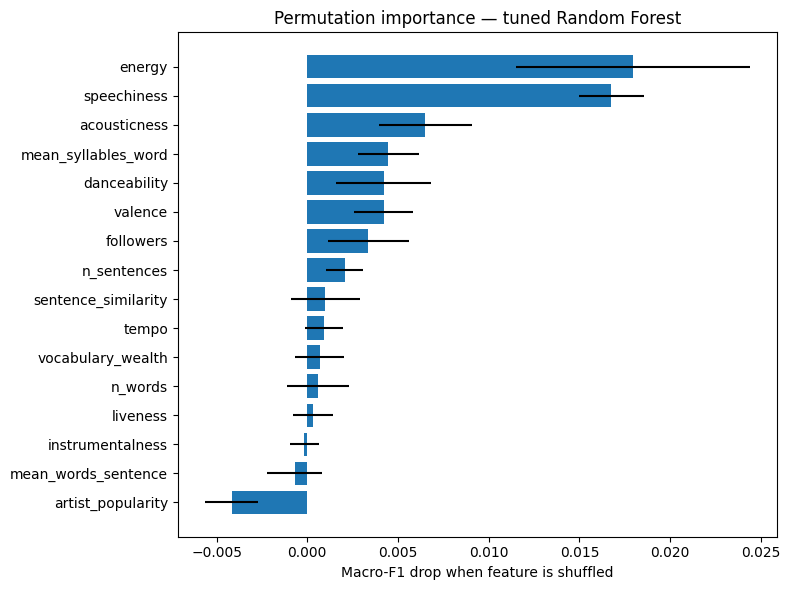

In [26]:
plteda.figure(figsize=(8, 6))
plteda.barh(importance["feature"][::-1], importance["mean_drop"][::-1],
            xerr=importance["std_drop"][::-1])
plteda.xlabel("Macro-F1 drop when feature is shuffled")
plteda.title("Permutation importance — tuned Random Forest")
plteda.tight_layout()
plteda.savefig(
    figures_path / "figure_permutation_importance_final_edaonay_2739415.pdf",
    bbox_inches="tight",
)
plteda.show()
